## EDA - Стоимость подержанного автомобиля

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from scipy import stats
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder


In [2]:
data = pd.read_csv("../cars.csv")

## Исследование исходных данных

In [3]:
data.columns

Index(['manufacturer_name', 'model_name', 'transmission', 'color',
       'odometer_value', 'year_produced', 'engine_fuel', 'engine_has_gas',
       'engine_type', 'engine_capacity', 'body_type', 'has_warranty', 'state',
       'drivetrain', 'price_usd', 'is_exchangeable', 'location_region',
       'number_of_photos', 'up_counter', 'feature_0', 'feature_1', 'feature_2',
       'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7',
       'feature_8', 'feature_9', 'duration_listed'],
      dtype='str')

Описание датасета

- 'manufacturer_name' - марка
- 'model_name' - модель
- 'transmission' - тип коробки
- 'color' - цвет
- 'odometer_value' - пробег
- 'year_produced' - год
- 'engine_fuel' - тип топлива
- 'engine_has_gas' - Is the car equipped with propane tank and tubing?
- 'engine_type'-  тип мотра
- 'engine_capacity' - обьем
- 'body_type' - кузов
- 'has_warranty' -гаран
- 'state' - состояние
- 'drivetrain' -привод
- 'price_usd'- цена(Целевой)
- 'is_exchangeable'- обмен
- 'location_region'- место
- 'number_of_photos' -колво фото
- 'up_counter'- Number of times the car has been upped, numerical.
- 'feature_0',
- 'feature_1',
- 'feature_2',
- 'feature_3',
- 'feature_4',
- 'feature_5',
- 'feature_6',
- 'feature_7',
- 'feature_8',
- 'feature_9', 
- 'duration_listed -Number of days the car is listed in the catalog.

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 38531 entries, 0 to 38530
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   manufacturer_name  38531 non-null  str    
 1   model_name         38531 non-null  str    
 2   transmission       38531 non-null  str    
 3   color              38531 non-null  str    
 4   odometer_value     38531 non-null  int64  
 5   year_produced      38531 non-null  int64  
 6   engine_fuel        38531 non-null  str    
 7   engine_has_gas     38531 non-null  bool   
 8   engine_type        38531 non-null  str    
 9   engine_capacity    38521 non-null  float64
 10  body_type          38531 non-null  str    
 11  has_warranty       38531 non-null  bool   
 12  state              38531 non-null  str    
 13  drivetrain         38531 non-null  str    
 14  price_usd          38531 non-null  float64
 15  is_exchangeable    38531 non-null  bool   
 16  location_region    38531 non-null

In [5]:
data.head()

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,...,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed
0,Subaru,Outback,automatic,silver,190000,2010,gasoline,False,gasoline,2.5,...,True,True,True,False,True,False,True,True,True,16
1,Subaru,Outback,automatic,blue,290000,2002,gasoline,False,gasoline,3.0,...,True,False,False,True,True,False,False,False,True,83
2,Subaru,Forester,automatic,red,402000,2001,gasoline,False,gasoline,2.5,...,True,False,False,False,False,False,False,True,True,151
3,Subaru,Impreza,mechanical,blue,10000,1999,gasoline,False,gasoline,3.0,...,False,False,False,False,False,False,False,False,False,86
4,Subaru,Legacy,automatic,black,280000,2001,gasoline,False,gasoline,2.5,...,True,False,True,True,False,False,False,False,True,7


array([[<Axes: title={'center': 'odometer_value'}>,
        <Axes: title={'center': 'year_produced'}>,
        <Axes: title={'center': 'engine_capacity'}>],
       [<Axes: title={'center': 'price_usd'}>,
        <Axes: title={'center': 'number_of_photos'}>,
        <Axes: title={'center': 'up_counter'}>],
       [<Axes: title={'center': 'duration_listed'}>, <Axes: >, <Axes: >]],
      dtype=object)

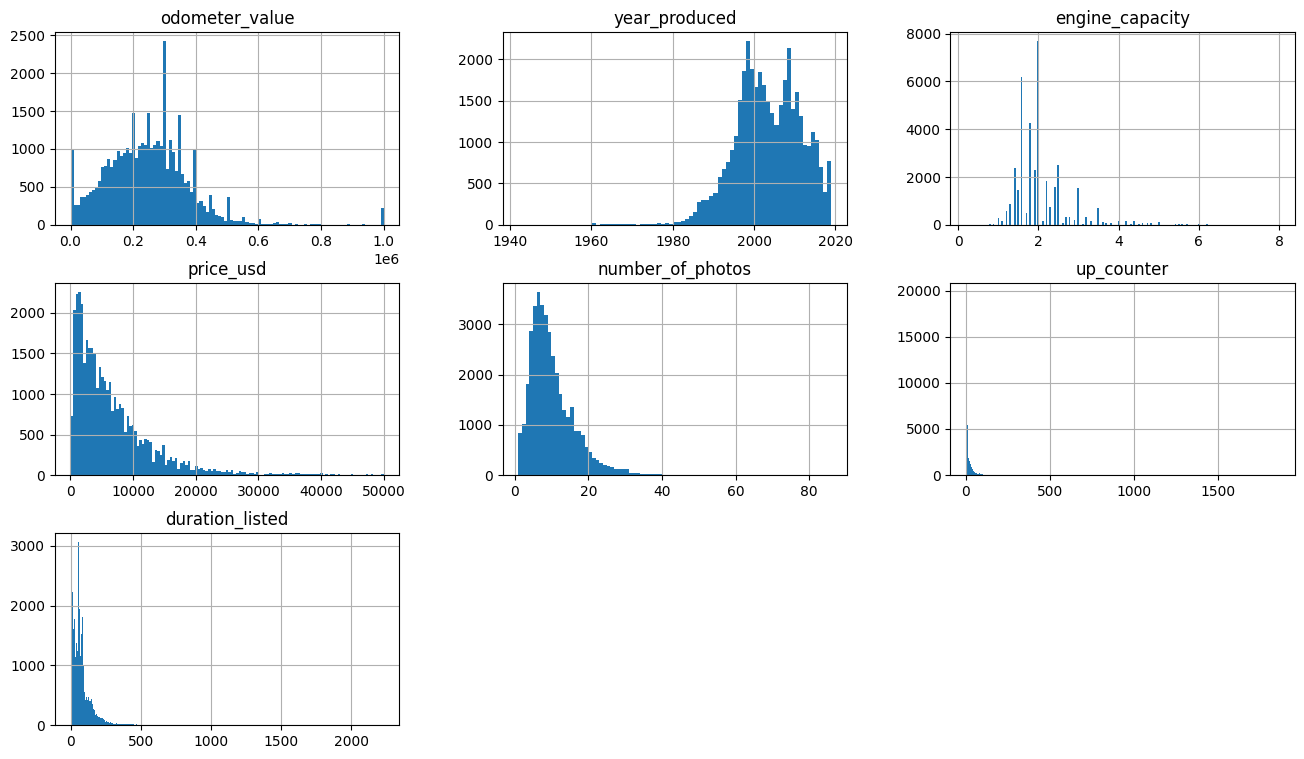

In [6]:
data.hist(bins='auto', figsize=(16,9))

In [7]:
bool_distrib_data = data.select_dtypes(bool)
bool_distrib_data = pd.DataFrame({True: bool_distrib_data.sum(), False: data.shape[0] - bool_distrib_data.sum()})
bool_distrib_data.transpose()

,engine_has_gas,has_warranty,is_exchangeable,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9
True,1347,449,13586,8806,23396,8624,10627,9304,13720,6588,10162,16003,22325
False,37184,38082,24945,29725,15135,29907,27904,29227,24811,31943,28369,22528,16206


### Очистка данных

In [8]:
data.duplicated().sum()

np.int64(40)

In [9]:
data = data.drop_duplicates(ignore_index=True)

In [10]:
(data.isna().sum()/data.shape[0]*100).sort_values(ascending=False)

engine_capacity      0.02598
manufacturer_name    0.00000
location_region      0.00000
feature_9            0.00000
feature_8            0.00000
feature_7            0.00000
feature_6            0.00000
feature_5            0.00000
feature_4            0.00000
feature_3            0.00000
feature_2            0.00000
feature_1            0.00000
feature_0            0.00000
up_counter           0.00000
number_of_photos     0.00000
is_exchangeable      0.00000
model_name           0.00000
price_usd            0.00000
drivetrain           0.00000
state                0.00000
has_warranty         0.00000
body_type            0.00000
engine_type          0.00000
engine_has_gas       0.00000
engine_fuel          0.00000
year_produced        0.00000
odometer_value       0.00000
color                0.00000
transmission         0.00000
duration_listed      0.00000
dtype: float64

Только в одном признаке это обьем мотора:
- модем заполнить модой тк это всего 10 пропусков

In [11]:
mode_val = data['engine_capacity'].mode()[0]
data.fillna({"engine_capacity": mode_val}, inplace=True)

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,...,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed
0,Subaru,Outback,automatic,silver,190000,2010,gasoline,False,gasoline,2.5,...,True,True,True,False,True,False,True,True,True,16
1,Subaru,Outback,automatic,blue,290000,2002,gasoline,False,gasoline,3.0,...,True,False,False,True,True,False,False,False,True,83
2,Subaru,Forester,automatic,red,402000,2001,gasoline,False,gasoline,2.5,...,True,False,False,False,False,False,False,True,True,151
3,Subaru,Impreza,mechanical,blue,10000,1999,gasoline,False,gasoline,3.0,...,False,False,False,False,False,False,False,False,False,86
4,Subaru,Legacy,automatic,black,280000,2001,gasoline,False,gasoline,2.5,...,True,False,True,True,False,False,False,False,True,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38486,Chrysler,300,automatic,silver,290000,2000,gasoline,False,gasoline,3.5,...,True,False,False,True,True,False,False,True,True,301
38487,Chrysler,PT Cruiser,mechanical,blue,321000,2004,diesel,False,diesel,2.2,...,True,False,False,True,True,False,False,True,True,317
38488,Chrysler,300,automatic,blue,777957,2000,gasoline,False,gasoline,3.5,...,True,False,False,True,True,False,False,True,True,369
38489,Chrysler,PT Cruiser,mechanical,black,20000,2001,gasoline,False,gasoline,2.0,...,True,False,False,False,False,False,False,False,True,490


In [12]:
(data.isna().sum()/data.shape[0]*100).sort_values(ascending=False)

manufacturer_name    0.0
model_name           0.0
feature_9            0.0
feature_8            0.0
feature_7            0.0
feature_6            0.0
feature_5            0.0
feature_4            0.0
feature_3            0.0
feature_2            0.0
feature_1            0.0
feature_0            0.0
up_counter           0.0
number_of_photos     0.0
location_region      0.0
is_exchangeable      0.0
price_usd            0.0
drivetrain           0.0
state                0.0
has_warranty         0.0
body_type            0.0
engine_capacity      0.0
engine_type          0.0
engine_has_gas       0.0
engine_fuel          0.0
year_produced        0.0
odometer_value       0.0
color                0.0
transmission         0.0
duration_listed      0.0
dtype: float64

Пропуски убранны

### Коррекция типов данных

- 0   manufacturer_name  38531 non-null  object 
- 1   model_name         38531 non-null  object 
- 2   transmission       38531 non-null  object 
- 3   color              38531 non-null  object 
- 4   odometer_value     38531 non-null  int64  
- 5   year_produced      38531 non-null  int64  
- 6   engine_fuel        38531 non-null  object 
- 7   engine_has_gas     38531 non-null  bool   
- 8   engine_type        38531 non-null  object 
- 9   engine_capacity    38521 non-null  float64
- 10  body_type          38531 non-null  object 
- 11  has_warranty       38531 non-null  bool   
- 12  state              38531 non-null  object 
- 13  drivetrain         38531 non-null  object 
- 14  price_usd          38531 non-null  float64
- 15  is_exchangeable    38531 non-null  bool   
- 16  location_region    38531 non-null  object 
- 17  number_of_photos   38531 non-null  int64  
- 18  up_counter         38531 non-null  int64  
- 19  feature_0          38531 non-null  bool   
- 20  feature_1          38531 non-null  bool   
- 21  feature_2          38531 non-null  bool   
- 22  feature_3          38531 non-null  bool   
- 23  feature_4          38531 non-null  bool   
- 24  feature_5          38531 non-null  bool   
- 25  feature_6          38531 non-null  bool   
- 26  feature_7          38531 non-null  bool   
- 27  feature_8          38531 non-null  bool   
- 28  feature_9          38531 non-null  bool   
- 29  duration_listed    38531 non-null  int64 

In [13]:
data["manufacturer_name"].unique()

<StringArray>
[       'Subaru',          'LADA',         'Dodge',           'УАЗ',
           'Kia',          'Opel',       'Москвич',    'Alfa Romeo',
         'Acura',         'Dacia',         'Lexus',    'Mitsubishi',
        'Lancia',       'Citroen',          'Mini',        'Jaguar',
       'Porsche',     'SsangYong',        'Daewoo',         'Geely',
           'ВАЗ',          'Fiat',          'Ford',       'Renault',
          'Seat',         'Rover',    'Volkswagen',         'Lifan',
          'Jeep',      'Cadillac',          'Audi',           'ЗАЗ',
        'Toyota',           'ГАЗ',         'Volvo',     'Chevrolet',
    'Great Wall',         'Buick',       'Pontiac',       'Lincoln',
       'Hyundai',        'Nissan',        'Suzuki',           'BMW',
         'Mazda',    'Land Rover',         'Iveco',         'Skoda',
          'Saab',      'Infiniti',         'Chery',         'Honda',
 'Mercedes-Benz',       'Peugeot',      'Chrysler']
Length: 55, dtype: str

In [14]:
data["year_produced"].unique().min()

np.int64(1942)

- manufacturer_name можем разбить на 3 ценовых сешмента
- model_name, color  - нельзя заменить на one hot,скорее всего от них избавимсмся если нет , корреляции на цену
- engine_type - поскольоку он очень схож с 'engine_fuel' но описывает меньше условийЮ его просто удалисм
- state можем заменить на ранговые
- transmission,  - можно замеить на бинарный признак
- drivetrain - можно замеить на ранговые 
-  location_region, body_type, engine_fuel - можно one-hot

In [15]:
data = data.drop(columns=['engine_type'])
data = data.drop(columns=['model_name'])
data = data.drop(columns=['color'])

In [16]:
data["transmission"].unique()

<StringArray>
['automatic', 'mechanical']
Length: 2, dtype: str

In [17]:
ordinal_encode_f1 = OrdinalEncoder(categories=[['emergency', 'owned', 'new']])
ordinal_encode_f2 = OrdinalEncoder(categories=[['front', 'rear', 'all']])
ordinal_encode_f3 = OrdinalEncoder(categories=[['mechanical','automatic']])


data["transmission"] = ordinal_encode_f3.fit_transform(data[["transmission"]])
data["state"] = ordinal_encode_f1.fit_transform(data[["state"]])
data["drivetrain"] = ordinal_encode_f2.fit_transform(data[["drivetrain"]])

In [18]:
dummies = pd.get_dummies(data[['location_region', 'body_type', 'engine_fuel']], 
                         prefix=['loc', 'body', 'fuel'],  # опционально, для читаемости
                         drop_first=False)  # можно drop_first=True для избежания мультикол
# Удаляем исходные категориальные столбцы
data = data.drop(columns=['location_region', 'body_type', 'engine_fuel'])

# Объединяем дамми-переменные с оставшимися данными
data = pd.concat([data, dummies], axis=1)

In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 38491 entries, 0 to 38490
Data columns (total 48 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   manufacturer_name     38491 non-null  str    
 1   transmission          38491 non-null  float64
 2   odometer_value        38491 non-null  int64  
 3   year_produced         38491 non-null  int64  
 4   engine_has_gas        38491 non-null  bool   
 5   engine_capacity       38491 non-null  float64
 6   has_warranty          38491 non-null  bool   
 7   state                 38491 non-null  float64
 8   drivetrain            38491 non-null  float64
 9   price_usd             38491 non-null  float64
 10  is_exchangeable       38491 non-null  bool   
 11  number_of_photos      38491 non-null  int64  
 12  up_counter            38491 non-null  int64  
 13  feature_0             38491 non-null  bool   
 14  feature_1             38491 non-null  bool   
 15  feature_2             38491 no

### сделаем преобразование марки в ценовой сегмент

In [20]:
manuf = data[['manufacturer_name',  "year_produced", "price_usd"]]
manuf

,manufacturer_name,year_produced,price_usd
0,Subaru,2010,10900.00
1,Subaru,2002,5000.00
2,Subaru,2001,2800.00
3,Subaru,1999,9999.00
4,Subaru,2001,2134.11
...,...,...,...
38486,Chrysler,2000,2750.00
38487,Chrysler,2004,4800.00
38488,Chrysler,2000,4300.00
38489,Chrysler,2001,4000.00


In [21]:
manuf = manuf[manuf['year_produced'] > 2010].reset_index(drop=True)
manuf

,manufacturer_name,year_produced,price_usd
0,Subaru,2011,14700.0
1,Subaru,2011,8600.0
2,Subaru,2014,12700.0
3,Subaru,2013,16500.0
4,Subaru,2011,14950.0
...,...,...,...
7199,Chrysler,2016,21800.0
7200,Chrysler,2012,19999.0
7201,Chrysler,2016,10350.0
7202,Chrysler,2015,26500.0


In [22]:
models = manuf['manufacturer_name'].unique()
diff = set(data['manufacturer_name'].unique()) - set(models)

for model in diff:
    print(f'{model}: {data[data["manufacturer_name"] == model].shape[0]}')


Lancia: 92
Rover: 235
Pontiac: 42
Москвич: 55


In [23]:
dic = dict()
for model in models:
    mod = manuf[manuf["manufacturer_name"] == model]
    mean = mod["price_usd"].sum()/mod.shape[0]
    dic[model] = round(mean, 2)
    
dic

{'Subaru': np.float64(16465.65),
 'LADA': np.float64(8626.81),
 'Dodge': np.float64(18770.75),
 'УАЗ': np.float64(8703.58),
 'Kia': np.float64(12858.97),
 'Opel': np.float64(10857.2),
 'Alfa Romeo': np.float64(9000.0),
 'Acura': np.float64(21792.13),
 'Dacia': np.float64(8794.54),
 'Lexus': np.float64(26756.15),
 'Mitsubishi': np.float64(15395.68),
 'Citroen': np.float64(9895.61),
 'Mini': np.float64(18513.8),
 'Jaguar': np.float64(29601.3),
 'Porsche': np.float64(32294.0),
 'SsangYong': np.float64(11145.75),
 'Daewoo': np.float64(2862.42),
 'Geely': np.float64(9189.12),
 'ВАЗ': np.float64(6725.64),
 'Fiat': np.float64(12282.87),
 'Ford': np.float64(12851.92),
 'Renault': np.float64(10292.24),
 'Seat': np.float64(10459.44),
 'Volkswagen': np.float64(13571.18),
 'Lifan': np.float64(8548.78),
 'Jeep': np.float64(21702.96),
 'Cadillac': np.float64(19370.71),
 'Audi': np.float64(18930.6),
 'ЗАЗ': np.float64(3268.48),
 'Toyota': np.float64(18331.84),
 'ГАЗ': np.float64(14429.33),
 'Volvo': 

In [24]:
prices = list(dic.values())
q25 = np.percentile(prices, 25)
q75 = np.percentile(prices, 75)

In [25]:
categorized = {}
for brand, price in dic.items():
    if price <= q25:
        categorized[brand] = 0
    elif price >= q75:
        categorized[brand] = 2
    else:
        categorized[brand] = 1

print(f"Пороги: бюджет до {round(q25, 2)}$, премиум от {round(q75, 2)}$")
for i in diff:
    categorized[i] = 0
print(categorized)

Пороги: бюджет до 10093.92$, премиум от 19150.66$
{'Subaru': 1, 'LADA': 0, 'Dodge': 1, 'УАЗ': 0, 'Kia': 1, 'Opel': 1, 'Alfa Romeo': 0, 'Acura': 2, 'Dacia': 0, 'Lexus': 2, 'Mitsubishi': 1, 'Citroen': 0, 'Mini': 1, 'Jaguar': 2, 'Porsche': 2, 'SsangYong': 1, 'Daewoo': 0, 'Geely': 0, 'ВАЗ': 0, 'Fiat': 1, 'Ford': 1, 'Renault': 1, 'Seat': 1, 'Volkswagen': 1, 'Lifan': 0, 'Jeep': 2, 'Cadillac': 2, 'Audi': 1, 'ЗАЗ': 0, 'Toyota': 1, 'ГАЗ': 1, 'Volvo': 1, 'Chevrolet': 1, 'Great Wall': 0, 'Buick': 1, 'Lincoln': 2, 'Hyundai': 1, 'Nissan': 1, 'Suzuki': 1, 'BMW': 2, 'Mazda': 1, 'Land Rover': 2, 'Iveco': 2, 'Skoda': 1, 'Saab': 1, 'Infiniti': 2, 'Chery': 0, 'Honda': 1, 'Mercedes-Benz': 2, 'Peugeot': 0, 'Chrysler': 2, 'Lancia': 0, 'Rover': 0, 'Pontiac': 0, 'Москвич': 0}


In [26]:
data['manufacturer_name'] = data['manufacturer_name'].map(categorized)
data

,manufacturer_name,transmission,odometer_value,year_produced,engine_has_gas,engine_capacity,has_warranty,state,drivetrain,price_usd,...,body_sedan,body_suv,body_universal,body_van,fuel_diesel,fuel_electric,fuel_gas,fuel_gasoline,fuel_hybrid-diesel,fuel_hybrid-petrol
0,1,1.0,190000,2010,False,2.5,False,1.0,2.0,10900.00,...,False,False,True,False,False,False,False,True,False,False
1,1,1.0,290000,2002,False,3.0,False,1.0,2.0,5000.00,...,False,False,True,False,False,False,False,True,False,False
2,1,1.0,402000,2001,False,2.5,False,1.0,2.0,2800.00,...,False,True,False,False,False,False,False,True,False,False
3,1,0.0,10000,1999,False,3.0,False,1.0,2.0,9999.00,...,True,False,False,False,False,False,False,True,False,False
4,1,1.0,280000,2001,False,2.5,False,1.0,2.0,2134.11,...,False,False,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38486,2,1.0,290000,2000,False,3.5,False,1.0,0.0,2750.00,...,True,False,False,False,False,False,False,True,False,False
38487,2,0.0,321000,2004,False,2.2,False,1.0,0.0,4800.00,...,False,False,False,False,True,False,False,False,False,False
38488,2,1.0,777957,2000,False,3.5,False,1.0,0.0,4300.00,...,True,False,False,False,False,False,False,True,False,False
38489,2,0.0,20000,2001,False,2.0,False,1.0,0.0,4000.00,...,False,False,False,False,False,False,False,True,False,False


In [27]:
col = data.columns
data[col[0]].head(1)

0    1
Name: manufacturer_name, dtype: int64

In [28]:
bool_cols = data.select_dtypes(include='bool').columns

data[bool_cols] = data[bool_cols].astype(int)

In [29]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 38491 entries, 0 to 38490
Data columns (total 48 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   manufacturer_name     38491 non-null  int64  
 1   transmission          38491 non-null  float64
 2   odometer_value        38491 non-null  int64  
 3   year_produced         38491 non-null  int64  
 4   engine_has_gas        38491 non-null  int64  
 5   engine_capacity       38491 non-null  float64
 6   has_warranty          38491 non-null  int64  
 7   state                 38491 non-null  float64
 8   drivetrain            38491 non-null  float64
 9   price_usd             38491 non-null  float64
 10  is_exchangeable       38491 non-null  int64  
 11  number_of_photos      38491 non-null  int64  
 12  up_counter            38491 non-null  int64  
 13  feature_0             38491 non-null  int64  
 14  feature_1             38491 non-null  int64  
 15  feature_2             38491 no

In [30]:
col = ["transmission", "state" ,"drivetrain"]
for i in col:
    data[i] = data[i].astype(int)

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 38491 entries, 0 to 38490
Data columns (total 48 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   manufacturer_name     38491 non-null  int64  
 1   transmission          38491 non-null  int64  
 2   odometer_value        38491 non-null  int64  
 3   year_produced         38491 non-null  int64  
 4   engine_has_gas        38491 non-null  int64  
 5   engine_capacity       38491 non-null  float64
 6   has_warranty          38491 non-null  int64  
 7   state                 38491 non-null  int64  
 8   drivetrain            38491 non-null  int64  
 9   price_usd             38491 non-null  float64
 10  is_exchangeable       38491 non-null  int64  
 11  number_of_photos      38491 non-null  int64  
 12  up_counter            38491 non-null  int64  
 13  feature_0             38491 non-null  int64  
 14  feature_1             38491 non-null  int64  
 15  feature_2             38491 no

# EDA

In [31]:
data.describe(percentiles=[0.25, 0.5, 0.75]).T

,count,mean,std,min,25%,50%,75%,max
manufacturer_name,38491.0,1.025590,0.549730,0.0,1.0,1.0,1.0,2.0
transmission,38491.0,0.334935,0.471974,0.0,0.0,0.0,1.0,1.0
odometer_value,38491.0,249058.310514,135918.326857,0.0,158000.0,250000.0,325000.0,1000000.0
year_produced,38491.0,2002.930815,8.056156,1942.0,1998.0,2003.0,2009.0,2019.0
engine_has_gas,38491.0,0.034995,0.183770,0.0,0.0,0.0,0.0,1.0
engine_capacity,38491.0,2.055524,0.671300,0.2,1.6,2.0,2.3,8.0
has_warranty,38491.0,0.010834,0.103521,0.0,0.0,0.0,0.0,1.0
state,38491.0,1.000935,0.141987,0.0,1.0,1.0,1.0,2.0
drivetrain,38491.0,0.419994,0.723477,0.0,0.0,0.0,1.0,2.0
price_usd,38491.0,6632.809227,6424.033741,1.0,2100.0,4800.0,8950.0,50000.0


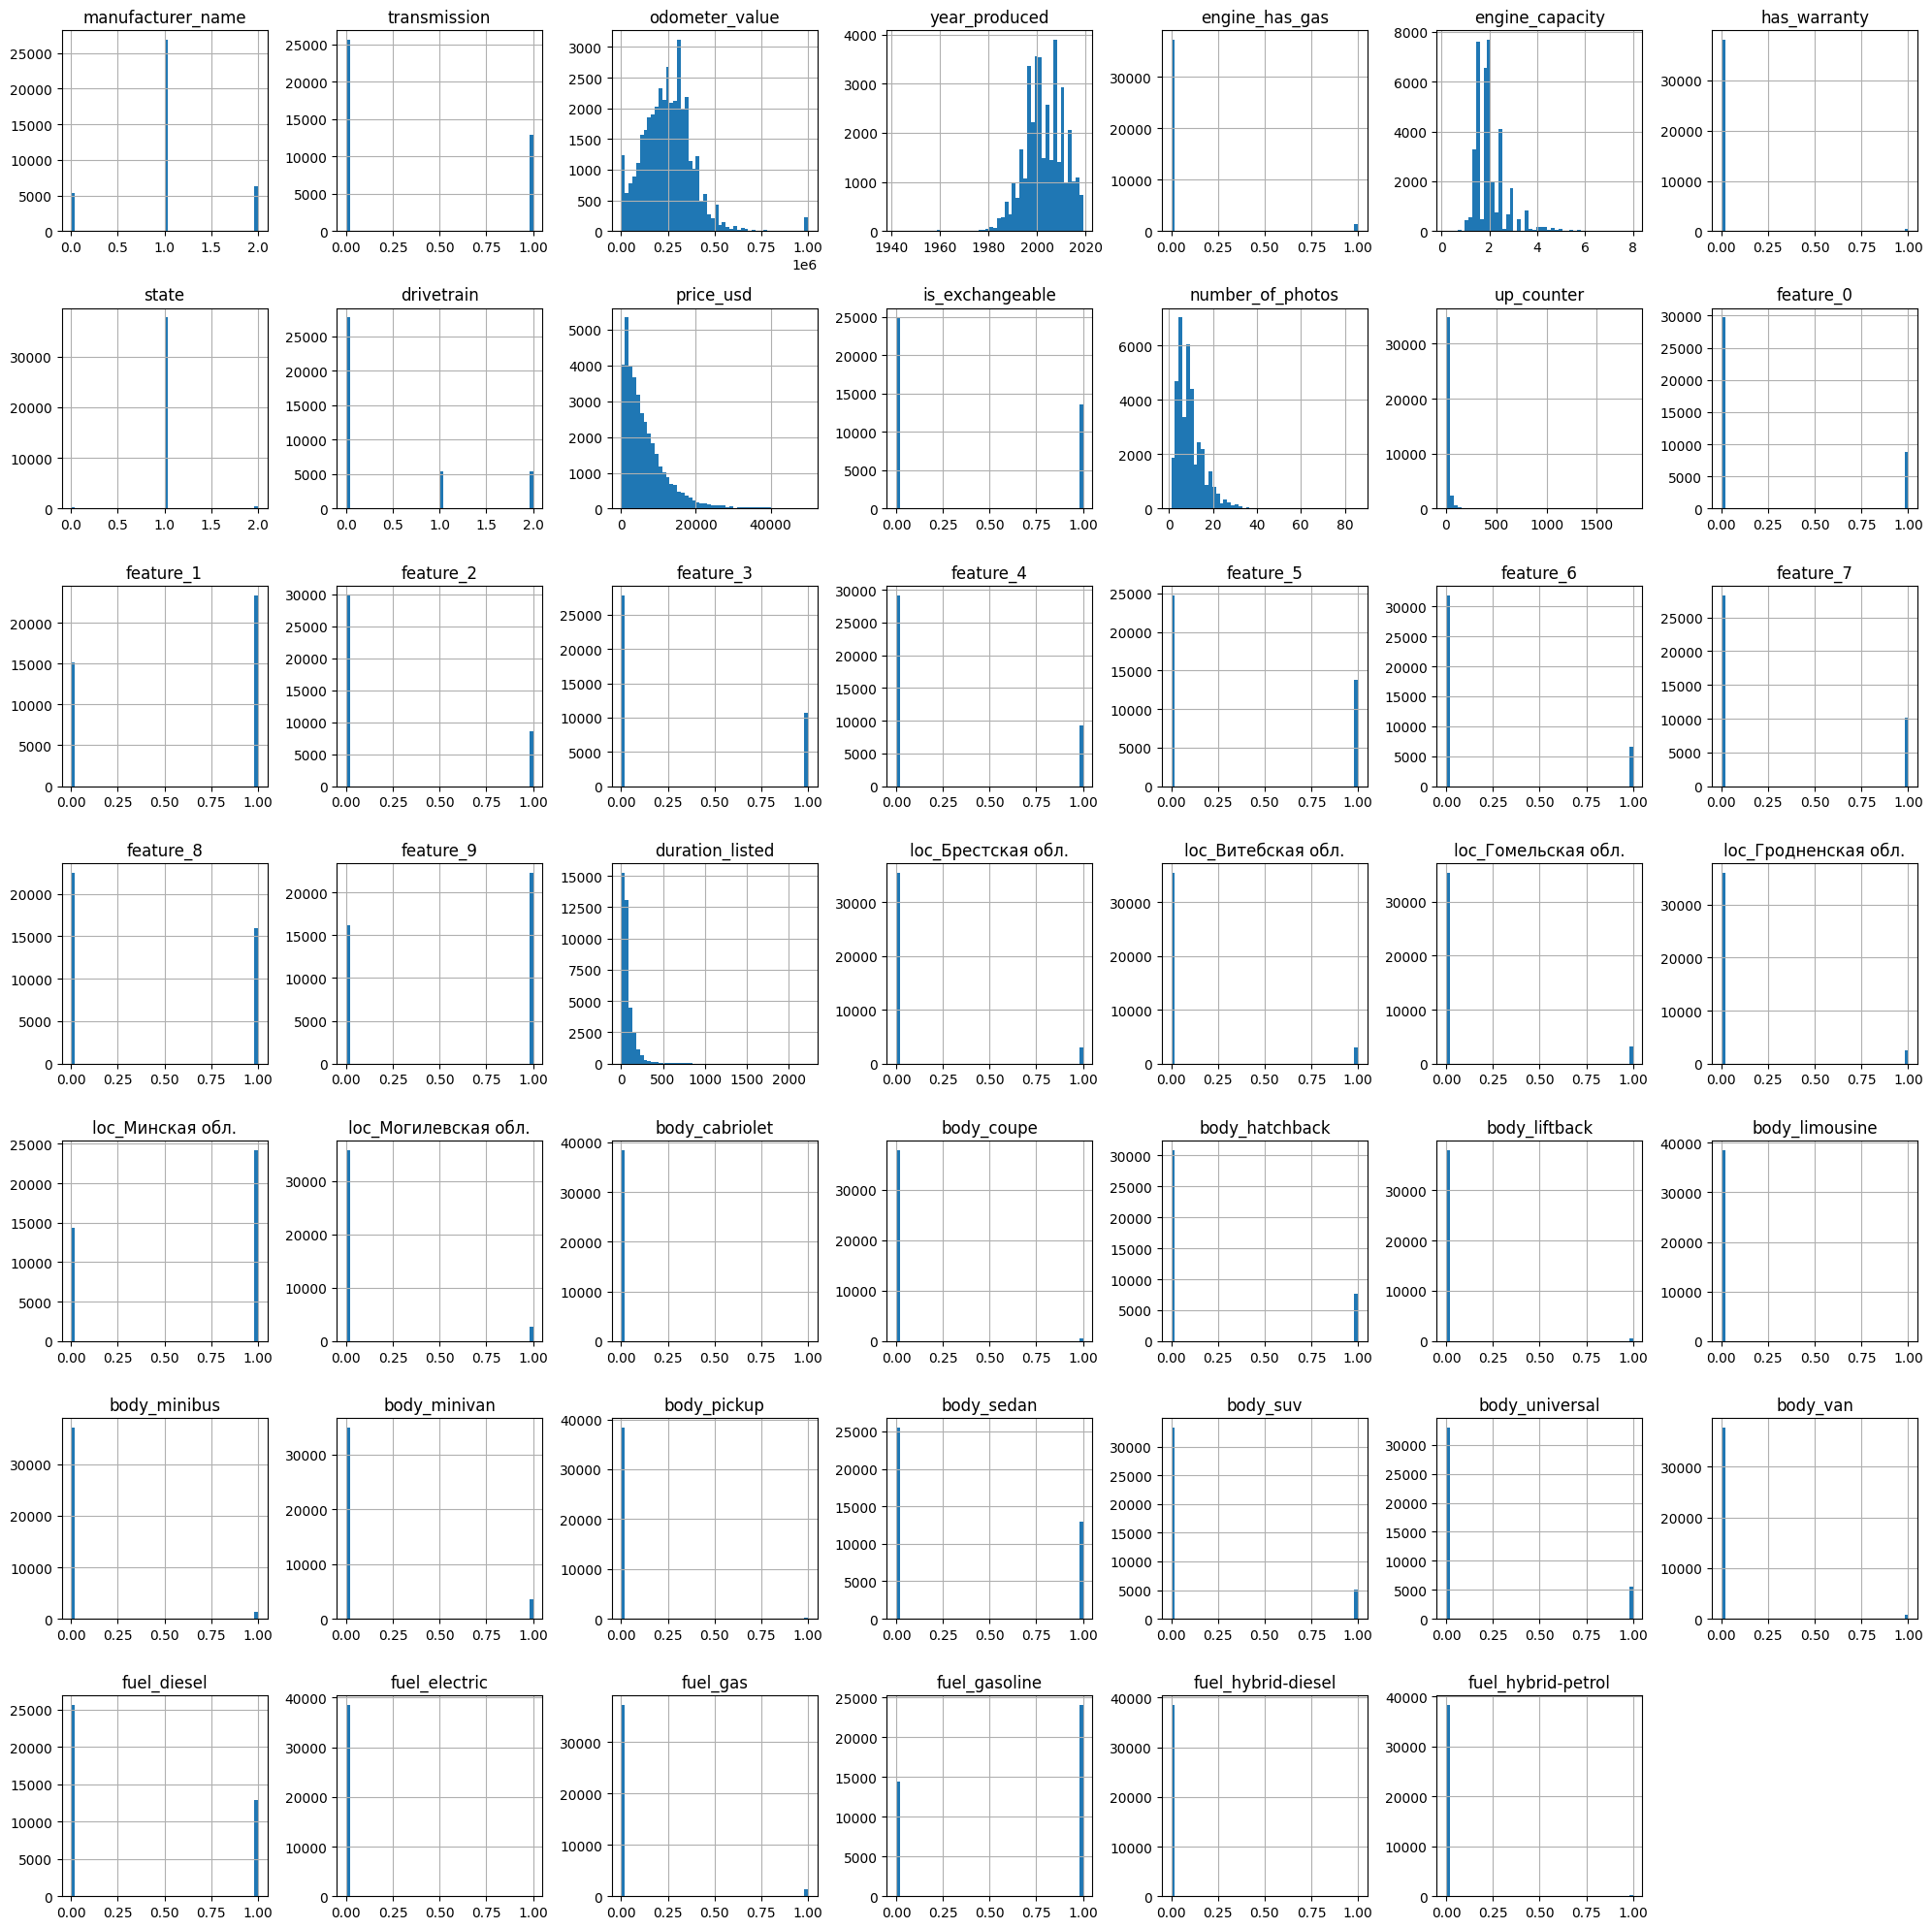

In [32]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
data.hist(bins=50, figsize=(20, 20))
plt.tight_layout()
plt.show()

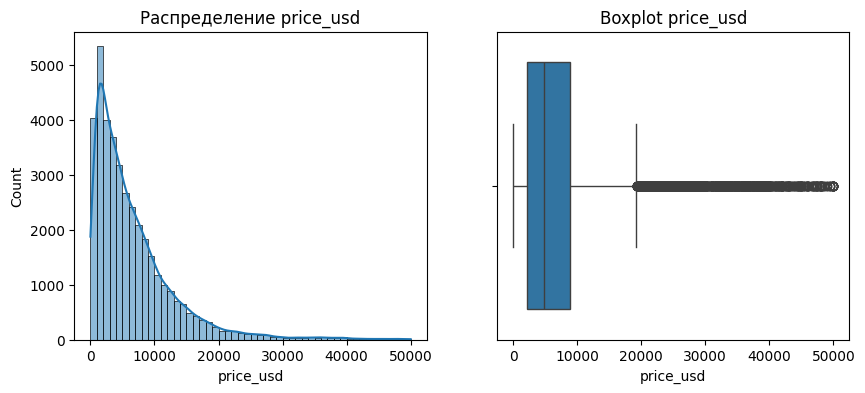

In [33]:
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
sns.histplot(data['price_usd'], bins=50, kde=True)
plt.title('Распределение price_usd')
plt.subplot(1,2,2)
sns.boxplot(x=data['price_usd'])
plt.title('Boxplot price_usd')
plt.show()

Корреляция признаков с price_usd:
 price_usd               1.000000
year_produced           0.705003
feature_7               0.499896
transmission            0.477357
feature_3               0.472265
feature_6               0.452793
feature_8               0.450778
body_suv                0.437118
feature_5               0.435959
drivetrain              0.407435
feature_2               0.339193
feature_4               0.337224
number_of_photos        0.316177
engine_capacity         0.297535
has_warranty            0.284813
state                   0.273540
feature_9               0.267967
manufacturer_name       0.260663
feature_1               0.257729
loc_Минская обл.        0.209581
fuel_diesel             0.086042
up_counter              0.057775
fuel_hybrid-petrol      0.056231
body_minibus            0.054788
body_pickup             0.046177
duration_listed         0.034312
body_cabriolet          0.029870
fuel_electric           0.027182
body_liftback           0.023260
body_cou

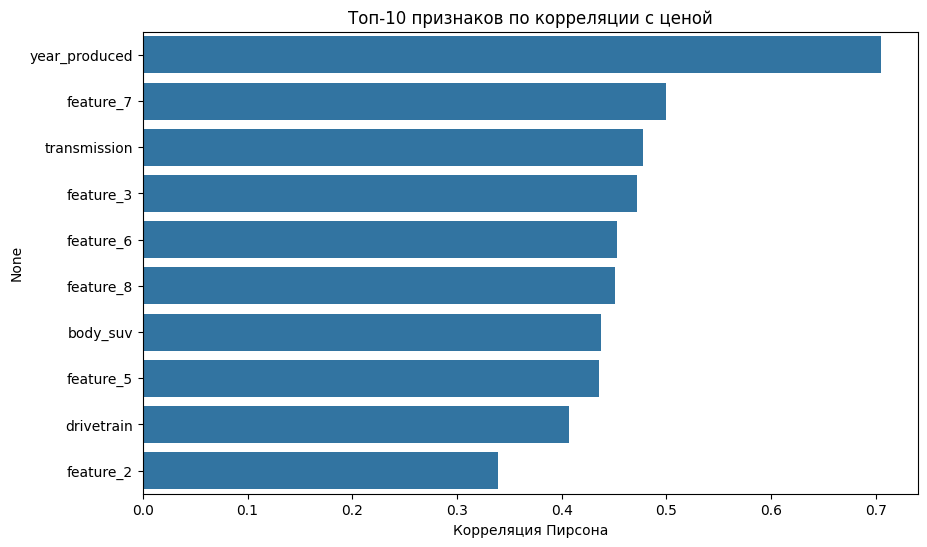

In [34]:
# Ячейка 4: корреляция с ценой (топ-10)
corr_with_price = data.corr(numeric_only=True)['price_usd'].sort_values(ascending=False)
print("Корреляция признаков с price_usd:\n", corr_with_price)

# Визуализация топ-10
top_features = corr_with_price.drop('price_usd').head(10).index
plt.figure(figsize=(10,6))
sns.barplot(x=corr_with_price[top_features].values, y=top_features)
plt.title('Топ-10 признаков по корреляции с ценой')
plt.xlabel('Корреляция Пирсона')
plt.show()

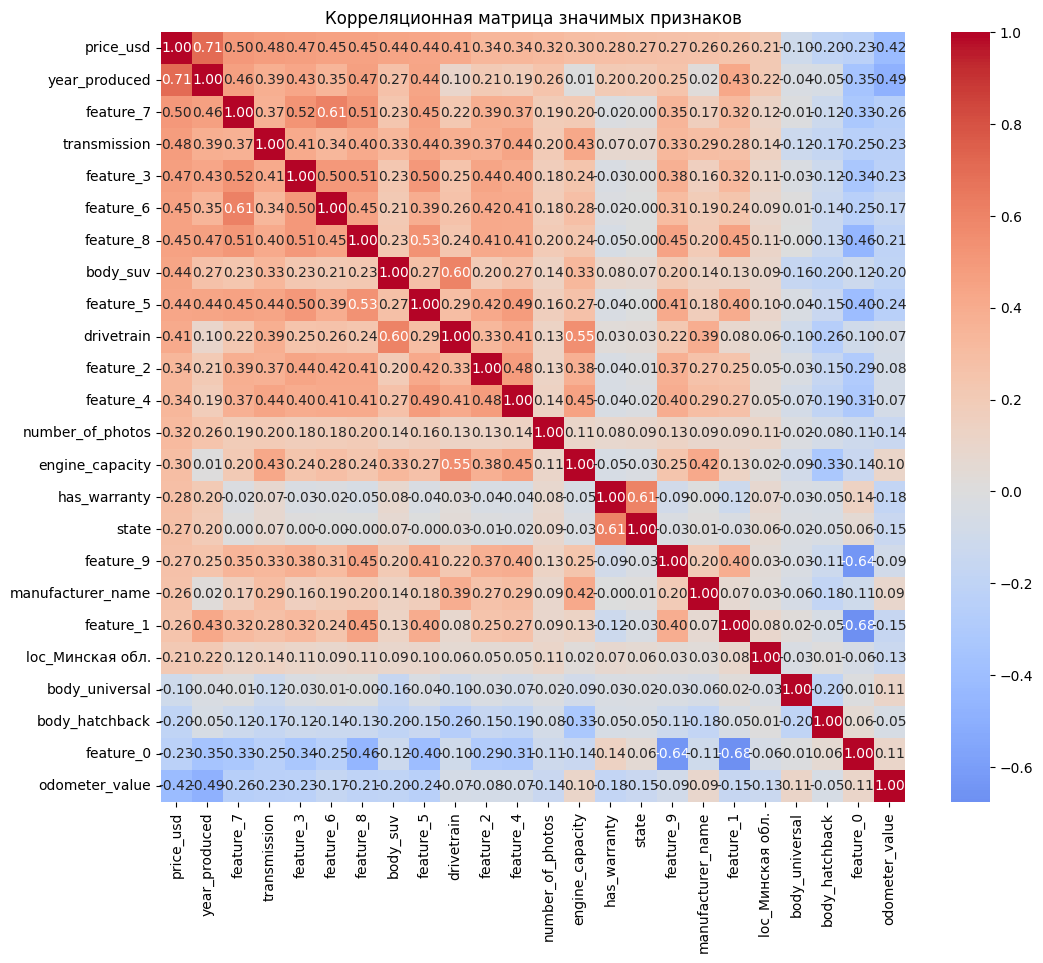

In [35]:
high_corr_features = corr_with_price[abs(corr_with_price) > 0.1].index
plt.figure(figsize=(12,10))
sns.heatmap(data[high_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица значимых признаков')
plt.show()

In [36]:
binary_cols = ['engine_has_gas', 'has_warranty', 'is_exchangeable'] + \
              [col for col in data.columns if col.startswith('feature_')] + \
              [col for col in data.columns if col.startswith('loc_')] + \
              [col for col in data.columns if col.startswith('body_')] + \
              [col for col in data.columns if col.startswith('fuel_')]
binary_cols = list(set(binary_cols) & set(data.columns))

price_by_binary = {}
for col in binary_cols:
    price_by_binary[col] = data.groupby(col)['price_usd'].mean()

price_by_binary_df = pd.DataFrame(price_by_binary).T
price_by_binary_df.columns = ['mean_price_when_0', 'mean_price_when_1']
price_by_binary_df['diff'] = price_by_binary_df['mean_price_when_1'] - price_by_binary_df['mean_price_when_0']
price_by_binary_df.sort_values('diff', ascending=False).head(20)

,mean_price_when_0,mean_price_when_1,diff
has_warranty,6441.332534,24115.503741,17674.171207
fuel_electric,6629.994308,17464.900000,10834.905692
body_suv,5527.716244,13767.959171,8240.242926
feature_6,5311.017361,13033.708725,7722.691364
feature_7,4709.600389,11994.929723,7285.329334
feature_3,4759.353579,11545.649582,6786.296003
feature_8,4190.389734,10066.087778,5875.698044
feature_5,4548.898329,10396.519119,5847.620790
feature_2,5462.116138,10688.414871,5226.298733
body_pickup,6615.607662,11748.207829,5132.600167


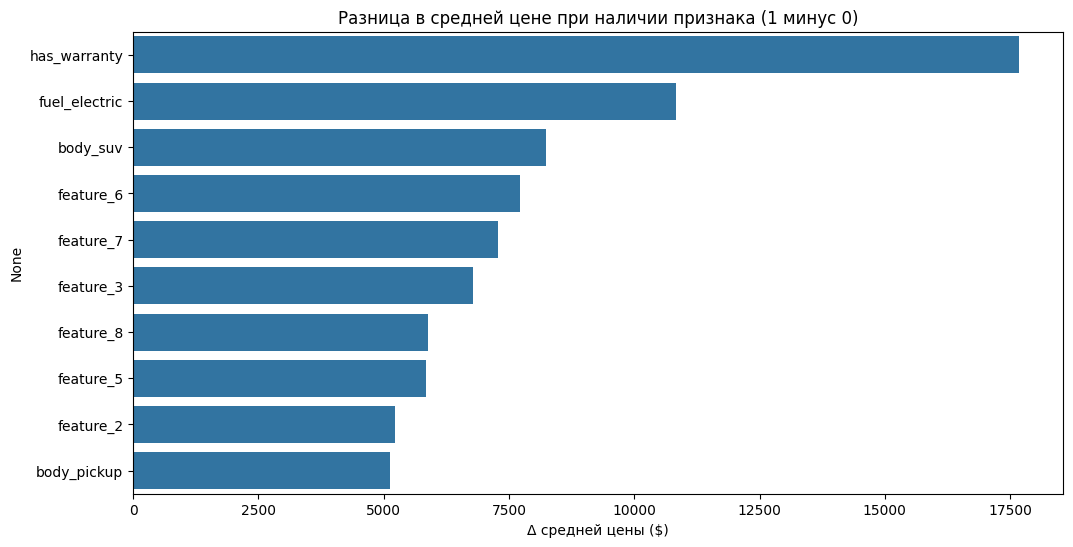

In [37]:
top_binary = price_by_binary_df['diff'].abs().sort_values(ascending=False).head(10).index
plt.figure(figsize=(12,6))
sns.barplot(data=price_by_binary_df.loc[top_binary], x='diff', y=top_binary)
plt.title('Разница в средней цене при наличии признака (1 минус 0)')
plt.xlabel('Δ средней цены ($)')
plt.show()

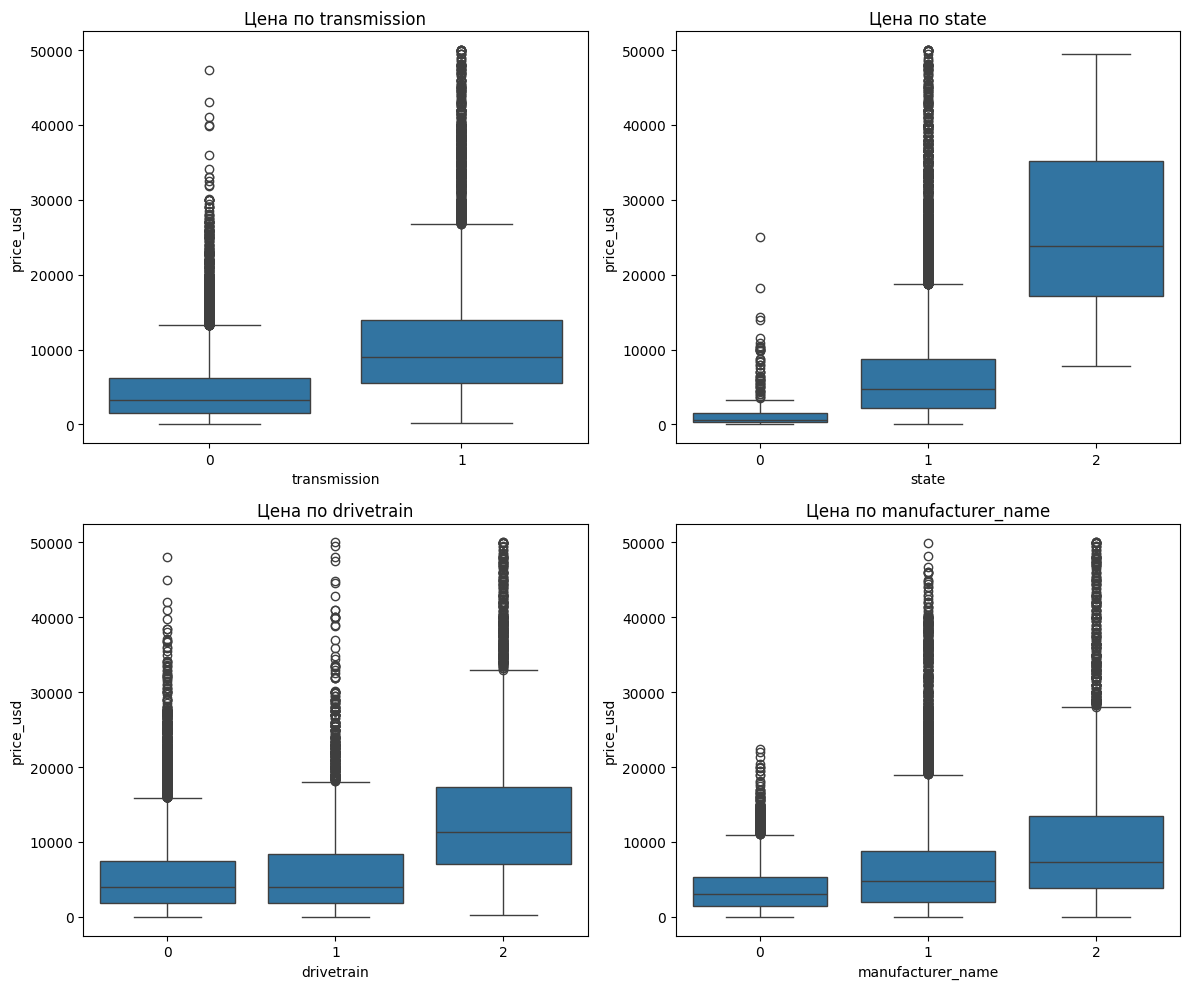

In [38]:
ordinal_cols = ['transmission', 'state', 'drivetrain', 'manufacturer_name']
fig, axes = plt.subplots(2,2, figsize=(12,10))
for ax, col in zip(axes.ravel(), ordinal_cols):
    sns.boxplot(data=data, x=col, y='price_usd', ax=ax)
    ax.set_title(f'Цена по {col}')
plt.tight_layout()
plt.show()

In [39]:
num_cols_for_outliers = ['odometer_value', 'year_produced', 'engine_capacity', 
                         'number_of_photos', 'up_counter', 'duration_listed']

outliers_summary = {}
for col in num_cols_for_outliers:
    z = np.abs(stats.zscore(data[col]))
    outliers = np.sum(z > 3)  # считаем выбросами значения с |z|>3
    outliers_summary[col] = outliers

outliers_df = pd.DataFrame.from_dict(outliers_summary, orient='index', columns=['количество выбросов'])
outliers_df['доля (%)'] = outliers_df['количество выбросов'] / len(data) * 100
outliers_df.sort_values('доля (%)', ascending=False)

,количество выбросов,доля (%)
engine_capacity,858,2.229093
number_of_photos,640,1.662726
duration_listed,601,1.561404
up_counter,465,1.208075
odometer_value,375,0.974254
year_produced,166,0.431270


все эти выбросы имеют физическое обоснование а значит не подлежат удалению

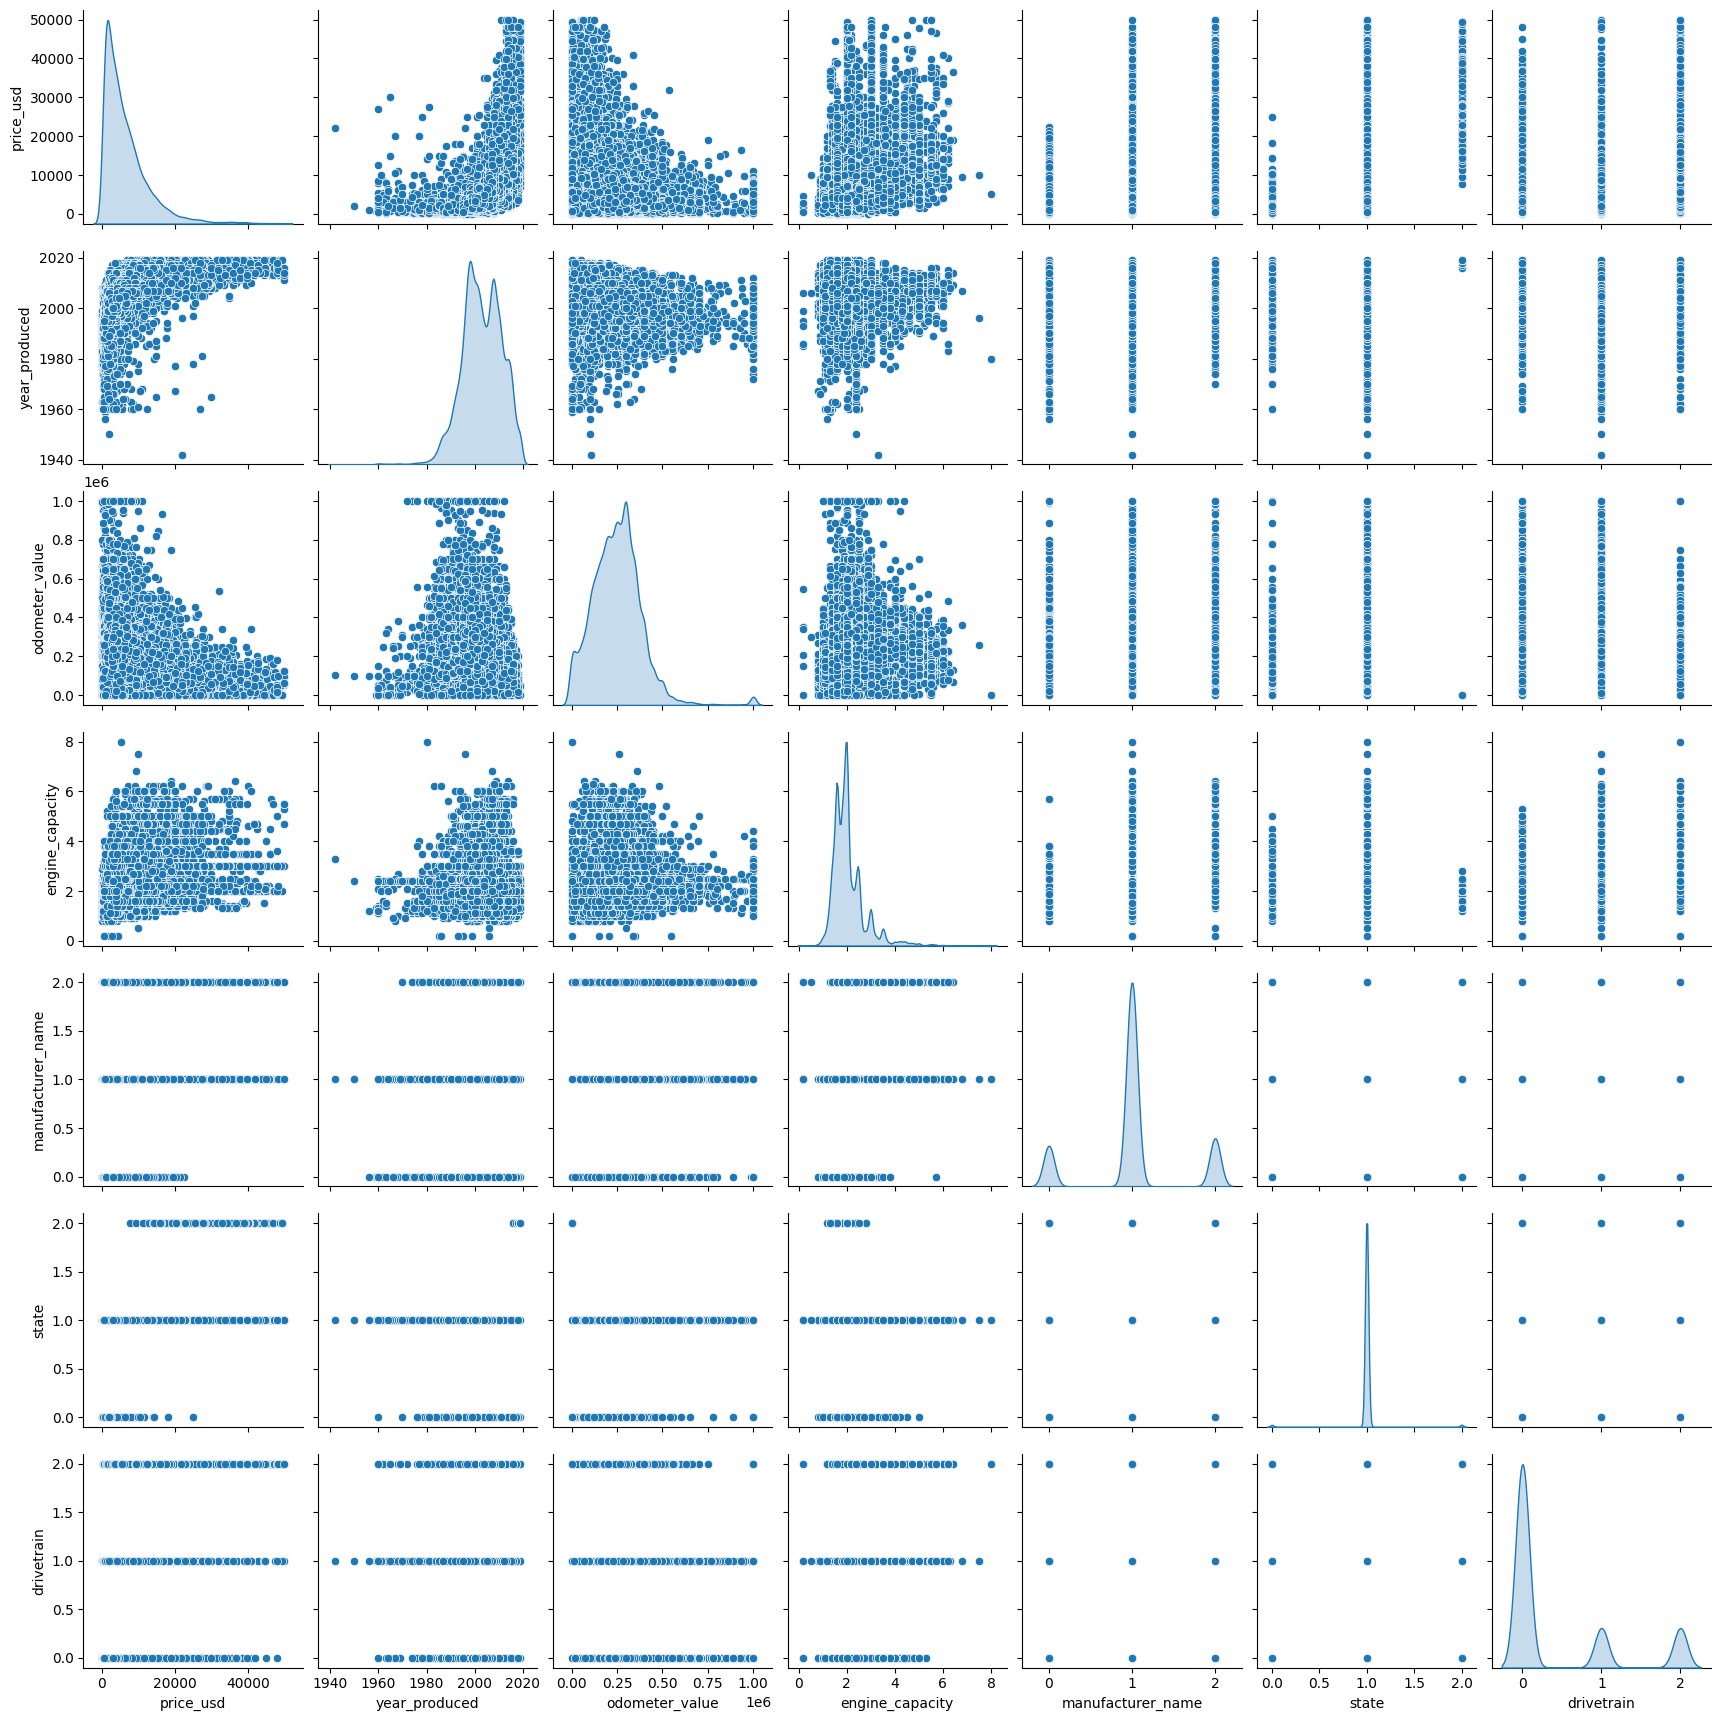

In [40]:
key_features = ['price_usd', 'year_produced', 'odometer_value', 'engine_capacity', 
                'manufacturer_name', 'state', 'drivetrain']
sns.pairplot(data[key_features], diag_kind='kde')
plt.show()

In [41]:
data.to_csv("cars_end.csv",index=False)

## Заключение

- В ходе выполненного анализа была проведена комплексная подготовка и исследование набора данных, содержащего информацию о подержанных автомобилях. Основные этапы работы включали очистку, преобразование признаков и глубокий разведочный анализ, что позволило сформировать качественную основу для последующего построения регрессионных моделей. 

Основные результаты и выводы:

1. Качество данных: 
- Исходный набор данных оказался достаточно чистым – обнаружено лишь 40 дубликатов (удалены) и незначительное число пропусков (10 записей в поле engine_capacity), которые были заполнены модой. Это говорит о высоком качестве исходной информации.

2. Преобразование признаков: С целью повышения информативности модели и снижения размерности был проведён ряд преобразований:

- Удалены избыточные (engine_type) и трудноинтерпретируемые (model_name, color) признаки.

- Выполнено кодирование порядковых переменных (transmission, state, drivetrain).

- Категориальные признаки (location_region, body_type, engine_fuel) преобразованы методом one-hot-кодирования.

- Наиболее важным преобразованием стало создание нового признака manufacturer_name, отражающего ценовой сегмент бренда (бюджетный, средний, премиум). Это позволило учесть влияние марки на стоимость автомобиля в компактной и информативной форме.

3. Ключевые факторы, влияющие на цену: Корреляционный анализ выявил следующие закономерности:

- Наибольшее положительное влияние на цену оказывает год выпуска автомобиля (year_produced, корреляция 0.71). Чем новее автомобиль, тем он дороже.

- Ожидаемо сильное отрицательное влияние имеет пробег (odometer_value, корреляция -0.42). С увеличением пробега цена падает.

- Ряд бинарных признаков (feature_*) и тип привода (drivetrain) также демонстрируют заметную корреляцию с ценой, что делает их потенциально важными предикторами.

- Анализ бинарных признаков показал, что наличие гарантии (has_warranty) или принадлежность к типам кузова «внедорожник» (body_suv) значительно увеличивают среднюю стоимость автомобиля.

4. Проверка данных на выбросы: Выявлено небольшое количество выбросов (менее 2.5%) в таких признаках, как объём двигателя, количество фотографий и пробег. Это нормально для реальных данных и, вероятно, не потребует агрессивных методов обработки, однако при построении моделей следует учитывать их влияние.

## итог

- Проведённый EDA позволил получить глубокое понимание структуры данных и выявить ключевые факторы, определяющие стоимость подержанного автомобиля. Данные очищены, преобразованы и готовы к использованию в задачах регрессии.

